In [1]:
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [2]:
asi_path = "/home/mduplessis/share/EXTERNAL/ASI/"
asi_files = glob.glob(asi_path + "*.nc")

In [3]:
asi = xr.open_mfdataset(asi_files, combine="by_coords")

In [ ]:
# calculate the mean sea ice concentration for across the Southern Ocean for each year

In [4]:
asi = asi.sel(lon=slice(-120, 120))

In [5]:
print(asi)
print('data vars:', list(asi.data_vars))
print('coords:', list(asi.coords))

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 365, lat: 251, lon: 2400)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2019-01-01 2019-01-02 ... 2019-12-31
  * lat      (lat) float64 2kB -75.0 -74.9 -74.8 -74.7 ... -50.2 -50.1 -50.0
  * lon      (lon) float64 19kB -119.9 -119.8 -119.7 ... 119.8 119.9 120.0
Data variables:
    sic      (time, lat, lon) float64 2GB dask.array<chunksize=(365, 251, 2400), meta=np.ndarray>
data vars: ['sic']
coords: ['time', 'lat', 'lon']


In [6]:
# Keep only November time steps and average within each November for every year.
november = asi["sic"].where(asi.time.dt.month == 11, drop=True)
november_mean_by_year = november.groupby("time.year").mean("time").compute()

years = november_mean_by_year["year"].values
n_years = len(years)
ncols = 5
nrows = int(np.ceil(n_years / ncols))

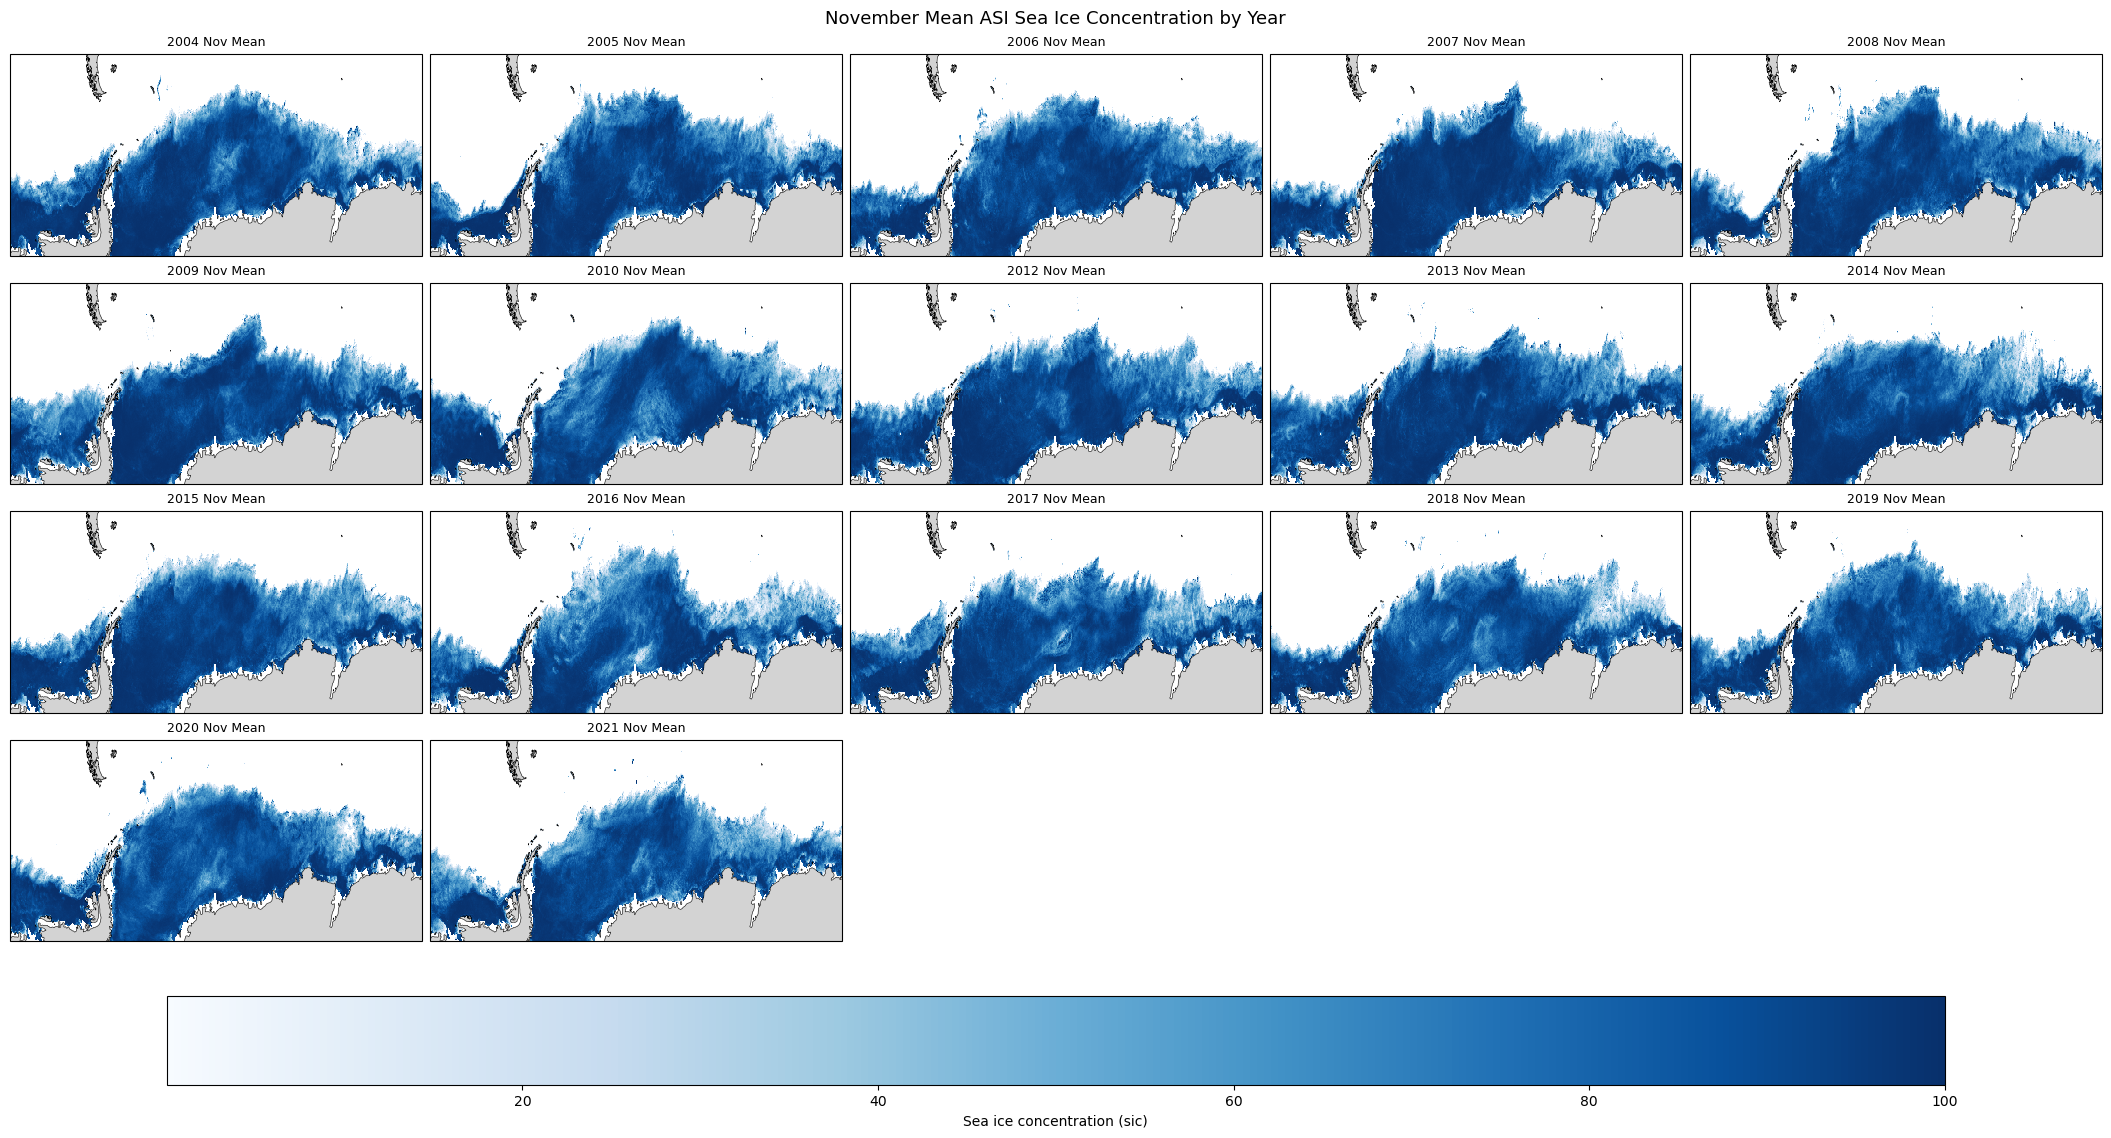

In [ ]:
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.2 * ncols, 2.8 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()

vmin = float(november_mean_by_year.min())
vmax = float(november_mean_by_year.max())

mappable = None
for i, year in enumerate(years):
    ax = axes[i]
    da = november_mean_by_year.sel(year=year)

    mappable = ax.pcolormesh(
        da["lon"],
        da["lat"],
        da,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="Blues",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_extent([
        float(da["lon"].min()),
        float(da["lon"].max()),
        float(da["lat"].min()),
        float(da["lat"].max()),
    ], crs=ccrs.PlateCarree())
    ax.set_aspect("auto")
    ax.coastlines(linewidth=0.4)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none")
    ax.set_title(f"{int(year)} Nov Mean", fontsize=9)

# Hide any unused subplot axes.
for j in range(n_years, len(axes)):
    axes[j].set_visible(False)

cbar = fig.colorbar(mappable, ax=axes[:n_years], orientation="horizontal", pad=0.05, shrink=0.85)
cbar.set_label("Sea ice concentration (sic)")

fig.suptitle("November Mean ASI Sea Ice Concentration by Year", fontsize=13)
plt.show()

In [ ]:
# Probability of sea ice presence for November across all years.
# A common threshold is sic >= 0.15 (15% concentration).
ice_presence_threshold = 0.15

november = asi["sic"].where(asi.time.dt.month == 11, drop=True)
ice_presence_likelihood = (november >= ice_presence_threshold).mean("time") * 100

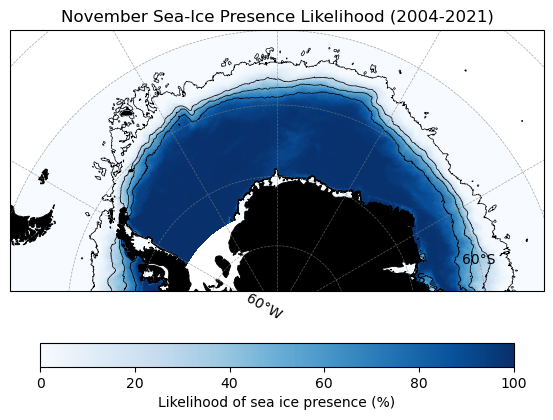

In [ ]:
fig, ax = plt.subplots(
    figsize=(6, 4),
    subplot_kw={"projection": ccrs.SouthPolarStereo()},
    constrained_layout=True,
)

pcm = ax.pcolormesh(
    ice_presence_likelihood["lon"],
    ice_presence_likelihood["lat"],
    ice_presence_likelihood,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="Blues",
    vmin=0,
    vmax=100,
)

cnt = ax.contour(
    ice_presence_likelihood["lon"],
    ice_presence_likelihood["lat"],
    ice_presence_likelihood,
    transform=ccrs.PlateCarree(),
    levels=[0, 25, 50, 75, 100],
    colors="k",
    linewidths=0.5,
    zorder=1
)

ax.set_extent([-70, 70, -80, -50], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="k", edgecolor="none", zorder=2)
ax.set_title("November Sea-Ice Presence Likelihood (2004-2021)")

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.7,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.06, shrink=0.8)
cbar.set_label("Likelihood of sea ice presence (%)")

plt.show()

In [7]:
import cmocean.cm as cmo

In [8]:
duacs = xr.open_mfdataset("/home/mduplessis/share/EXTERNAL/DUACS/2024/*.nc")

/tmp/ipykernel_768420/1430483956.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  duacs = xr.open_mfdataset("/home/mduplessis/share/EXTERNAL/DUACS/2024/*.nc")


In [9]:
duacs = duacs.sel(latitude=slice(-90, -15), longitude=slice(-160, 160))

In [11]:
duacs['gos'] = np.sqrt(duacs['ugos']**2 + duacs['vgos']**2)

Animation saved as november_2019_sea_ice_duacs.gif


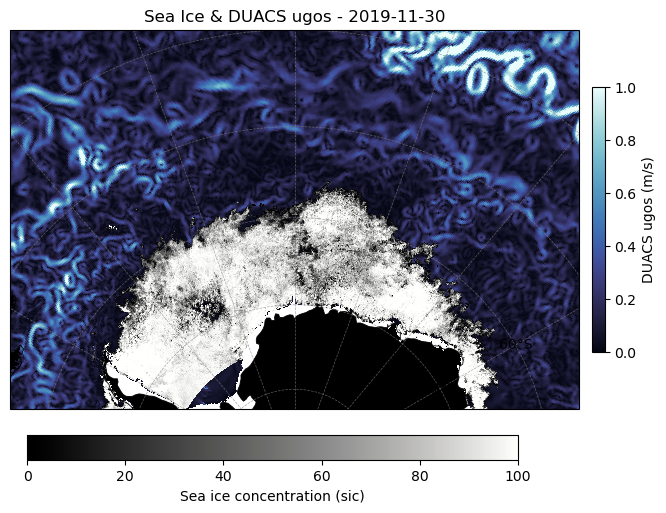

In [17]:
# Animation of November 2021 sea ice concentration and 2024 DUACS ugos, both as colormaps, saved as GIF
import matplotlib.animation as animation

# Select November 2019 data for sea ice and 2024 for DUACS
sic_nov_2019 = asi["sic"].sel(time=slice("2019-11-01", "2019-11-30"))
ugos_nov_2024 = duacs["gos"].sel(time=slice("2024-11-01", "2024-11-30"))

fig, ax = plt.subplots(
    figsize=(7, 5),
    subplot_kw={"projection": ccrs.SouthPolarStereo()},
    constrained_layout=True,
)

# Plot ugos (bone) on below
gos = ax.pcolormesh(
    duacs["longitude"],
    duacs["latitude"],
    ugos_nov_2024.isel(time=0),
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap=cmo.ice,
    vmin=0,
    vmax=1,
    alpha=1,
)

# Plot sea ice concentration (Blues)
pcm = ax.pcolormesh(
    sic_nov_2019["lon"],
    sic_nov_2019["lat"],
    sic_nov_2019.isel(time=0),
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap=cmo.gray,
    vmin=0,
    vmax=100,
    alpha=1,
)

ax.set_extent([-40, 40, -80, -40], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="k", edgecolor="none")
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.7,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = True
gl.left_labels = True
gl.bottom_labels = False

# Colorbars for both colormaps
cbar1 = fig.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.06, shrink=0.8)
cbar1.set_label("Sea ice concentration (sic)")
cbar2 = fig.colorbar(gos, ax=ax, orientation="vertical", pad=0.02, shrink=0.7)
cbar2.set_label("DUACS ugos (m/s)")

# Animation function
def animate(i):
    gos.set_array(ugos_nov_2024.isel(time=i).values.ravel())
    pcm.set_array(sic_nov_2019.isel(time=i).values.ravel())
    ax.set_title(f"Sea Ice & DUACS ugos - {str(sic_nov_2019.time.values[i])[:10]}")
    return [pcm, gos]

ani = animation.FuncAnimation(
    fig, animate, frames=len(sic_nov_2019.time), interval=400, blit=True
)

gif_path = "november_2019_sea_ice_duacs.gif"
ani.save(gif_path, writer="pillow", fps=5)
print(f"Animation saved as {gif_path}")

plt.show()

In [ ]:
# Calculate mean sea ice area for each day and plot seasonal cycle for each year
import pandas as pd

# Assume grid cell area is constant and approximate (polar stereographic, 25km x 25km)
grid_cell_area_km2 = 25 * 25  # km^2

# Threshold for sea ice presence (15%)
sic_threshold = 0.15

# Mask for sea ice presence
ice_mask = asi['sic'] >= sic_threshold

# Calculate daily sea ice area (sum of grid cells with ice * area per cell)
daily_area = (ice_mask * grid_cell_area_km2).sum(dim=["lat", "lon"])

# Convert to DataFrame for easier plotting
df_area = daily_area.to_dataframe().reset_index()
df_area['date'] = pd.to_datetime(df_area['time'])
df_area['year'] = df_area['date'].dt.year
df_area['doy'] = df_area['date'].dt.dayofyear

# Pivot to get each year as a column for seasonal cycle plot
pivot = df_area.pivot(index='doy', columns='year', values='sic')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(ax=ax, legend=False, alpha=0.7)
ax.set_xlabel('Day of Year')
ax.set_ylabel('Sea Ice Area (km²)')
ax.set_title('Seasonal Cycle of Sea Ice Area by Year')
plt.show()

In [15]:
# Calculate weighted mean sea ice area for each day and plot seasonal cycle for each year
import pandas as pd

# Earth's radius in km
R = 6371.0

# Get lat/lon arrays
lats = asi['lat'].values
lons = asi['lon'].values

# Calculate area weights for each grid cell (approximate, using latitude)
dlat = np.deg2rad(lats[1] - lats[0])
dlons = np.deg2rad(lons[1] - lons[0])
lat_radians = np.deg2rad(lats)
weights = np.cos(lat_radians)
weights_2d = weights[:, np.newaxis] * np.ones(len(lons))
cell_area = (R**2) * dlat * dlons * weights_2d  # in km^2

# Threshold for sea ice presence (15%)
sic_threshold = 0.15
ice_mask = asi['sic'] >= sic_threshold

daily_area_weighted = (ice_mask * cell_area).sum(dim=["lat", "lon"])
df_area = daily_area_weighted.to_dataframe().reset_index()
df_area['date'] = pd.to_datetime(df_area['time'])
df_area['year'] = df_area['date'].dt.year
df_area['doy'] = df_area['date'].dt.dayofyear

In [ ]:
# Despike: Remove anomalously low points (e.g., below 3 std from rolling median)
df_area = daily_area_weighted.to_dataframe().reset_index()
df_area['date'] = pd.to_datetime(df_area['time'])
df_area['year'] = df_area['date'].dt.year
df_area['doy'] = df_area['date'].dt.dayofyear

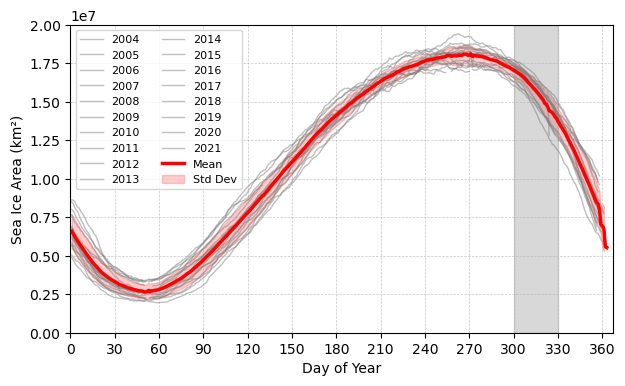

In [52]:


# Pivot to get each year as a column for seasonal cycle plot (by day of year)
pivot = df_area.pivot(index='doy', columns='year', values='sic')
window = 50
median = pivot.rolling(window, min_periods=21, center=True).median()
std = pivot.rolling(window, min_periods=21, center=True).std()
mask = (pivot < (median - std))
pivot_despiked = pivot.mask(mask, np.nan)

# Calculate mean and std across years (ignoring NaNs)
mean = pivot_despiked.mean(axis=1)
stddev = pivot_despiked.std(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
pivot_despiked.plot(ax=ax, color='gray', linewidth=1, alpha=0.5, legend=False)
ax.plot(mean.index, mean.values, color='red', linewidth=2.5, label='Mean')
ax.fill_between(mean.index, mean-stddev, mean+stddev, color='red', alpha=0.2, label='Std Dev')

ax.set_xlabel('Day of Year')
ax.set_ylabel('Sea Ice Area (km²)')
# ax.set_title('Seasonal Cycle of Weighted Sea Ice Area by Year (Despiked)')
ax.legend(loc=2, ncol=2, fontsize=8)
ax.set_xlim(0, 367)
ax.xaxis.set_major_locator(plt.MaxNLocator(13))
ax.fill_betweenx([0, 2e7], 300, 330, color='gray', alpha=0.3)  # Highlight November
ax.set_ylim(0, 2e7)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

In [ ]:
# Plot map of mean sea ice (2016-2021) minus mean sea ice (2004-2015)

# Select years
sic = asi['sic']
mean_2016_2021 = sic.sel(time=sic['time.year'].isin(range(2016, 2022))).mean('time')
mean_2004_2015 = sic.sel(time=sic['time.year'].isin(range(2004, 2016))).mean('time')
diff = mean_2016_2021 - mean_2004_2015

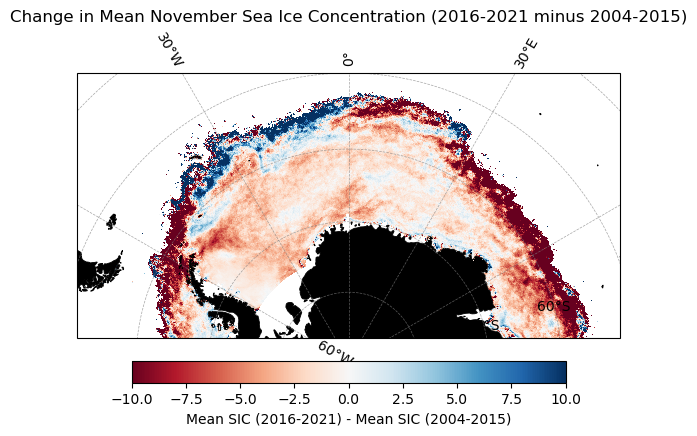

In [56]:


fig, ax = plt.subplots(figsize=(7, 5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
pcm = ax.pcolormesh(
    asi['lon'], asi['lat'], diff,
    transform=ccrs.PlateCarree(),
    cmap='RdBu', vmin=-10, vmax=10, shading='auto')
ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="k", edgecolor="none")
ax.set_extent([-70, 70, -80, -50], crs=ccrs.PlateCarree())
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.7,
    linestyle="--",
)
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.06, shrink=0.8)
cbar.set_label('Mean SIC (2016-2021) - Mean SIC (2004-2015)')
ax.set_title('Change in Mean November Sea Ice Concentration (2016-2021 minus 2004-2015)')
plt.show()

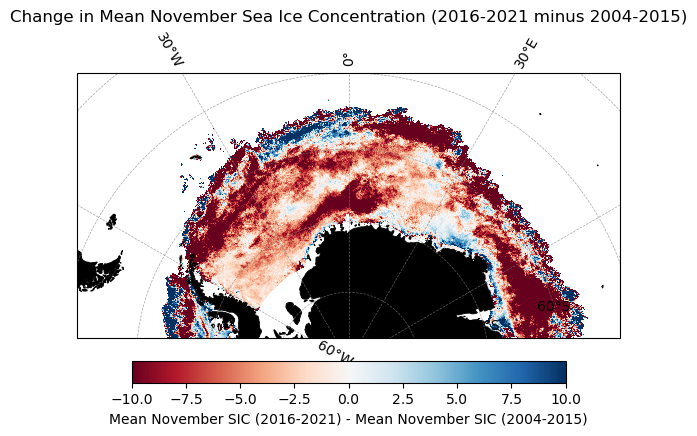

In [58]:
# Plot map of mean November sea ice (2016-2021) minus mean November sea ice (2004-2015)

# Select only November data for each period
sic = asi['sic']
nov_2016_2021 = sic.sel(time=((sic['time.year'] >= 2016) & (sic['time.year'] <= 2021)) & (sic['time.month'] == 11))
nov_2004_2015 = sic.sel(time=((sic['time.year'] >= 2004) & (sic['time.year'] <= 2015)) & (sic['time.month'] == 11))
mean_nov_2016_2021 = nov_2016_2021.mean('time')
mean_nov_2004_2015 = nov_2004_2015.mean('time')
diff_nov = mean_nov_2016_2021 - mean_nov_2004_2015

fig, ax = plt.subplots(figsize=(7, 5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
pcm = ax.pcolormesh(
    asi['lon'], asi['lat'], diff_nov,
    transform=ccrs.PlateCarree(),
    cmap='RdBu', vmin=-10, vmax=10, shading='auto')
ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="k", edgecolor="none")
ax.set_extent([-70, 70, -80, -50], crs=ccrs.PlateCarree())
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.7,
    linestyle="--",
)
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.06, shrink=0.8)
cbar.set_label('Mean November SIC (2016-2021) - Mean November SIC (2004-2015)')
ax.set_title('Change in Mean November Sea Ice Concentration (2016-2021 minus 2004-2015)')
plt.show()